In [1]:
import numpy as np
import pandas as pd

In [17]:
pd.set_option("display.max_columns", None)

In [7]:
all_runs = pd.read_csv("../../TRACE/all_runs.csv")

In [8]:
all_runs.columns

Index(['microstructure', 'version', 'taufactor.status',
       'taufactor.config_hash', 'taufactor.resolved_version',
       'taufactor.porosity', 'taufactor.D_eff', 'taufactor.tau_solver',
       'taufactor.tau_reconciled', 'taufactor.constrictivity',
       'taufactor.elapsed_s', 'berg_voxel.status', 'berg_voxel.config_hash',
       'berg_voxel.resolved_version', 'berg_voxel.n_paths', 'berg_voxel.Omega',
       'berg_voxel.Omega_c', 'berg_voxel.phi', 'berg_voxel.phi_c',
       'berg_voxel.I_decomp', 'berg_voxel.I_total_direct',
       'berg_voxel.current_loss_rel', 'berg_voxel.tau_sq_c',
       'berg_voxel.user_tortuosity', 'berg_voxel.C_c',
       'berg_voxel.one_over_C_c', 'berg_voxel.one_over_F_direct',
       'berg_voxel.F_direct',
       'berg_voxel.user_tortuosity_inferred_from_C_F_phi_c',
       'berg_voxel.user_tortuosity_inferred_from_C_F_phi',
       'berg_voxel.decomposition_method', 'berg_voxel.decomposition_engine',
       'berg_voxel.decomposition_elapsed_s', 'berg_voxe

In [39]:
imp_cols = ['microstructure','type',
       'taufactor.porosity', 'taufactor.D_eff', 'taufactor.tau_solver',
       'taufactor.tau_reconciled', 'taufactor.constrictivity',
       'berg_cc.n_bodies', 'berg_cc.n_throats',
       'berg_cc.n_streamtubes','berg_cc.iota_sq_g',
       'berg_cc.iota_sq_c', 'berg_cc.tau_sq_c', 'berg_cc.C_c',
       'berg_cc.consistency', 'berg_cc.phi_total', 'berg_cc.phi_c',
       'berg_cc.F_total', 'berg_cc.F_c']

voxels_berg_col = ['berg_voxel.phi', 'berg_voxel.phi_c',
       'berg_voxel.I_decomp', 'berg_voxel.I_total_direct',
       'berg_voxel.current_loss_rel', 'berg_voxel.tau_sq_c',
       'berg_voxel.user_tortuosity', 'berg_voxel.C_c',
       'berg_voxel.one_over_C_c', 'berg_voxel.one_over_F_direct',
       'berg_voxel.F_direct',
       'berg_voxel.user_tortuosity_inferred_from_C_F_phi_c',
       'berg_voxel.user_tortuosity_inferred_from_C_F_phi',
       'berg_voxel.one_over_F',
       'berg_voxel.F', 'berg_voxel.L_sample']

In [46]:
all_runs['type']=all_runs['microstructure'].apply(lambda x: x.rsplit('_', 1)[0])
all_runs['berg_cc.one_over_F'] = all_runs['berg_cc.F_total'].apply(lambda x: 1/x)
all_runs['berg_voxel.one_over_F_calc'] = (all_runs['berg_voxel.tau_sq_c']*all_runs['berg_voxel.phi_c']/all_runs['berg_voxel.C_c'])
all_runs.groupby('type')[['taufactor.D_eff','berg_cc.F_total','berg_voxel.F','berg_cc.one_over_F','berg_voxel.one_over_F_calc']].mean()

,taufactor.D_eff,berg_cc.F_total,berg_voxel.F,berg_cc.one_over_F,berg_voxel.one_over_F_calc
type,,,,,
Coarse_microstructure,0.012120,125.971408,111.790437,0.009527,0.004715
Fine_microstructure,0.133795,13.628419,7.670754,0.074823,0.051151
Medium_microstructure,0.045171,37.557958,26.129524,0.030447,0.017387


In [47]:
from sklearn.metrics import r2_score, mean_squared_error

In [52]:
print("R² Score:", r2_score(all_runs['berg_cc.one_over_F'], all_runs['berg_voxel.one_over_F_calc']))
print("Mean Squared Error:", mean_squared_error(all_runs['berg_cc.one_over_F'], all_runs['berg_voxel.one_over_F_calc']))

R² Score: 0.6913038396906412
Mean Squared Error: 0.00028574565054532384


In [54]:
print("R² Score:", r2_score(all_runs['taufactor.D_eff'],all_runs['berg_cc.one_over_F'],))
print("Mean Squared Error:", mean_squared_error(all_runs['berg_cc.one_over_F'], all_runs['taufactor.D_eff']))

R² Score: 0.5336532470508963
Mean Squared Error: 0.0015380399323802693


In [21]:
import matplotlib.pyplot as plt

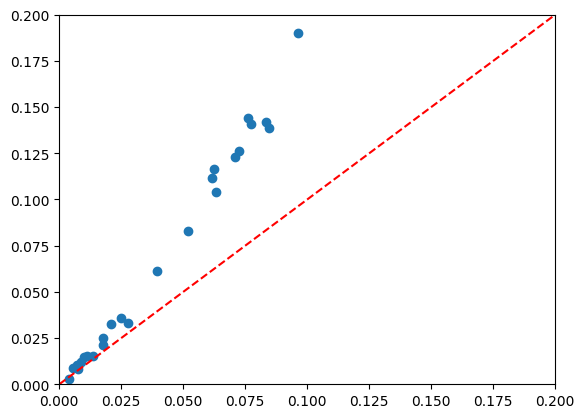

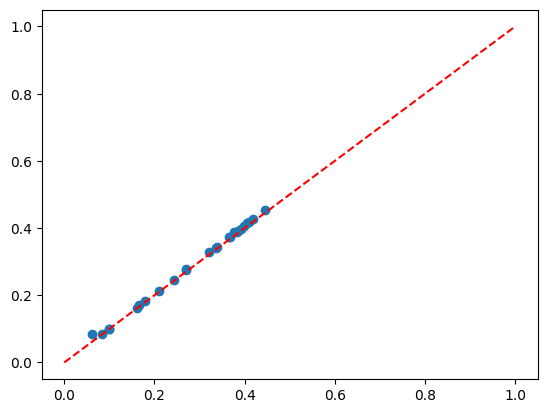

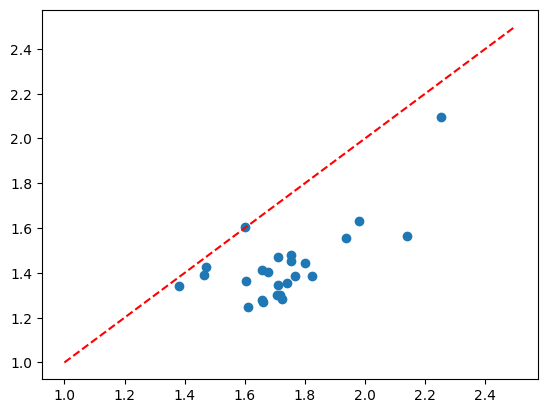

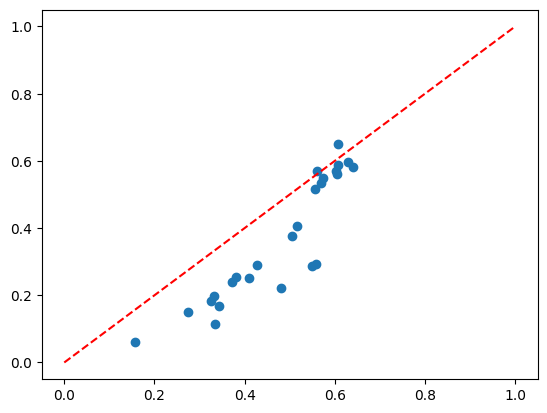

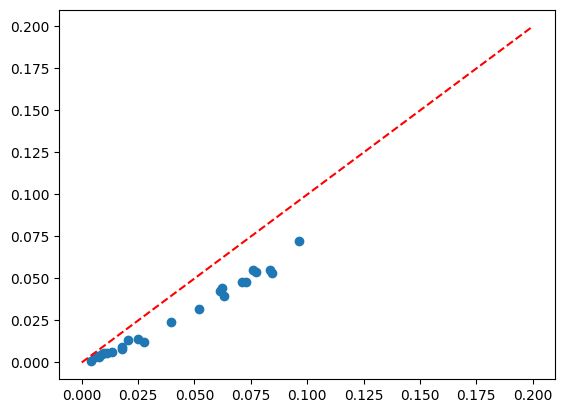

In [34]:
plt.scatter(1/all_runs[imp_cols]['berg_cc.F_total'], all_runs[imp_cols]['taufactor.D_eff'])
plt.plot([0, 0.2], [0, 0.2], color='red', linestyle='--')
plt.xlim(0,0.2)
plt.ylim(0,0.2)
plt.show()

plt.scatter(all_runs[imp_cols]['berg_cc.phi_total'], all_runs[imp_cols]['taufactor.porosity'])
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
# plt.xlim(0, 0.2)
# plt.ylim(0, 0.2)
plt.show()

plt.scatter(np.sqrt(1/all_runs[imp_cols]['berg_cc.tau_sq_c']), all_runs[imp_cols]['taufactor.tau_reconciled'])
plt.plot([1, 2.5], [1, 2.5], color='red', linestyle='--')
# plt.xlim(0, 0.2)
# plt.ylim(0, 0.2)
plt.show()

plt.scatter(1/all_runs[imp_cols]['berg_cc.C_c'], all_runs[imp_cols]['taufactor.constrictivity'])
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
# plt.xlim(0, 0.2)
# plt.ylim(0, 0.2)
plt.show()

plt.scatter(1/all_runs[imp_cols]['berg_cc.F_total'], (all_runs['berg_voxel.tau_sq_c']*all_runs['berg_voxel.phi_c'])/all_runs['berg_voxel.C_c'])
plt.plot([0, 0.2], [0, 0.2], color='red', linestyle='--')
# plt.xlim(0, 0.2)
# plt.ylim(0, 0.2)
plt.show()

In [55]:
import sys
from pathlib import Path
import numpy as np

# make analysis/artificial importable
REPO_ROOT = Path.cwd().resolve().parent.parent  # adjust if your notebook lives elsewhere
sys.path.insert(0, str(REPO_ROOT / "analysis" / "artificial"))

from throat_removal import prune_and_recompute

# load a microstructure's raw arrays (not the cached berg_cc results —
# this recomputes the network from scratch since throat removal needs the
# PoreNetwork object, not just cached metrics)
ms_dir = REPO_ROOT / "data" / "microstructure1"
body_array = np.load(ms_dir / "body_array.npy")
segmented  = np.load(ms_dir / "segmented.npy")

config = {"min_throat_size": 5, "direction": "x", "surface_axis": 0, "phase_id": 3}

result = prune_and_recompute(body_array, segmented, config, verbose=False)

result["n_throats_removed"], result["n_bodies_newly_isolated"], result["solve_failed"]

[build_network_arrays] 290 throat(s) used uniform-pipe fallback.
[build_network_arrays] 404 bodies, 658 throats indexed.
Current threshold I_threshold = 5.432e-11


/Users/rochan/miniconda3/envs/rbenv/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


[build_network_arrays] 286 throat(s) used uniform-pipe fallback.
[build_network_arrays] 404 bodies, 651 throats indexed.
Current threshold I_threshold = 5.911e-11


/Users/rochan/miniconda3/envs/rbenv/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


(7, 0, None)

In [56]:
import pandas as pd
pd.Series(result["baseline"]).to_frame("baseline").join(
    pd.Series(result["pruned"]).to_frame("pruned")
).join(pd.Series(result["delta"]).to_frame("delta"))

,baseline,pruned,delta
n_bodies,404.000000,404.000000,0.000000
n_throats,658.000000,651.000000,-7.000000
n_streamtubes,340.000000,333.000000,-7.000000
n_fallback_throats,290.000000,286.000000,-4.000000
Omega,339307.000000,339307.000000,0.000000
Omega_c,316824.066667,316474.200000,-349.866667
V_stuck_total,0.000000,0.000000,0.000000
iota_sq_g,0.227719,0.223086,-0.004633
iota_sq_c,0.243879,0.239181,-0.004698
tau_sq_c,0.379481,0.377655,-0.001826
